In [27]:
import sys
print(sys.executable)

c:\Users\Dell\OneDrive\Attachments\Desktop\coding\Early disease Prediction\venv\Scripts\python.exe


In [28]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn
import joblib
import shap

print("All ML libraries are working!")

All ML libraries are working!


In [29]:
import pandas as pd

df = pd.read_csv("../dataset/health_data.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [30]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (768, 9)

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [31]:
import pandas as pd

df = pd.read_csv("../dataset/health_data.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [32]:
import pandas as pd
import numpy as np

print("Environment ready for Early Disease Prediction")

Environment ready for Early Disease Prediction


In [33]:
import pandas as pd
import numpy as np

df = pd.read_csv("../dataset/health_data.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [34]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape: (768, 9)

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [36]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [37]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [38]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [39]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [40]:
print(y.value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


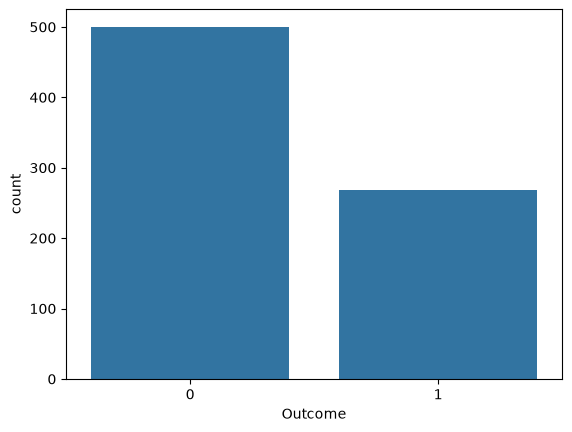

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Outcome", data=df)
plt.show()

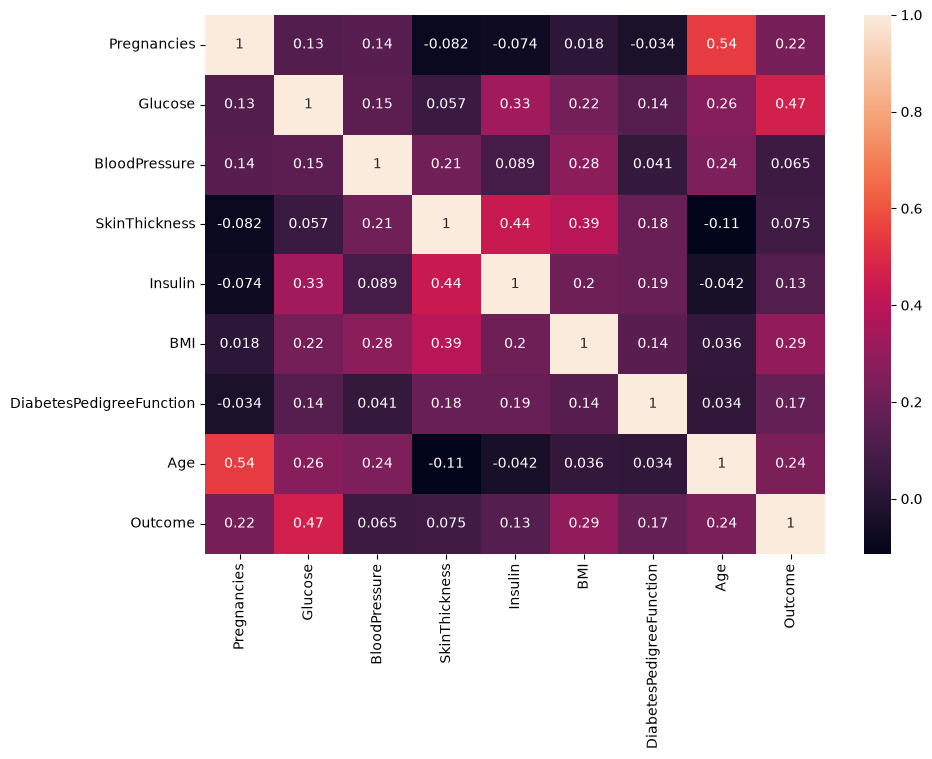

In [42]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

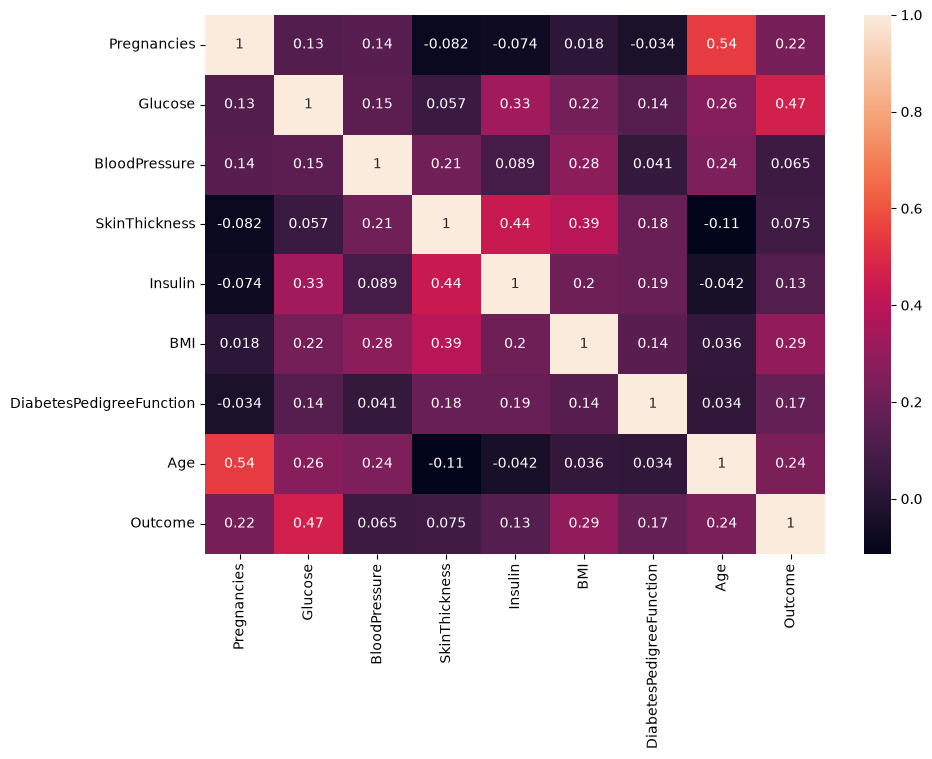

In [43]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [44]:
from sklearn.model_selection import train_test_split

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(614, 8)
(154, 8)


In [45]:
from sklearn.model_selection import train_test_split

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(614, 8)
(154, 8)


In [46]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 0 0 0 0 0 0 1 0 1]


In [47]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 0 0 0 0 0 0 1 0 1]


In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.7142857142857143
Precision: 0.6086956521739131
Recall   : 0.5185185185185185
F1 Score : 0.56


In [49]:
print(confusion_matrix(y_test, y_pred))

[[82 18]
 [26 28]]


In [50]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [51]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 0 0 0 0 0 0 1 0 1]


In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.7142857142857143
Precision: 0.6086956521739131
Recall   : 0.5185185185185185
F1 Score : 0.56


In [53]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[82 18]
 [26 28]]


In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [55]:
rf_pred = rf_model.predict(X_test)

print(rf_pred[:10])

[1 0 0 0 0 0 0 1 0 1]


In [56]:
print("Random Forest Results")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Random Forest Results
Accuracy : 0.7467532467532467
Precision: 0.6530612244897959
Recall   : 0.5925925925925926
F1 Score : 0.6213592233009708


In [57]:
lr_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred)
}

rf_results = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1": f1_score(y_test, rf_pred)
}

comparison = pd.DataFrame(
    [lr_results, rf_results],
    index=["Logistic Regression", "Random Forest"]
)

comparison

,Accuracy,Precision,Recall,F1
Logistic Regression,0.714286,0.608696,0.518519,0.560000
Random Forest,0.746753,0.653061,0.592593,0.621359


In [58]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

Glucose                     0.266073
BMI                         0.161420
Age                         0.130861
DiabetesPedigreeFunction    0.127089
BloodPressure               0.086335
Pregnancies                 0.084277
Insulin                     0.073752
SkinThickness               0.070194
dtype: float64


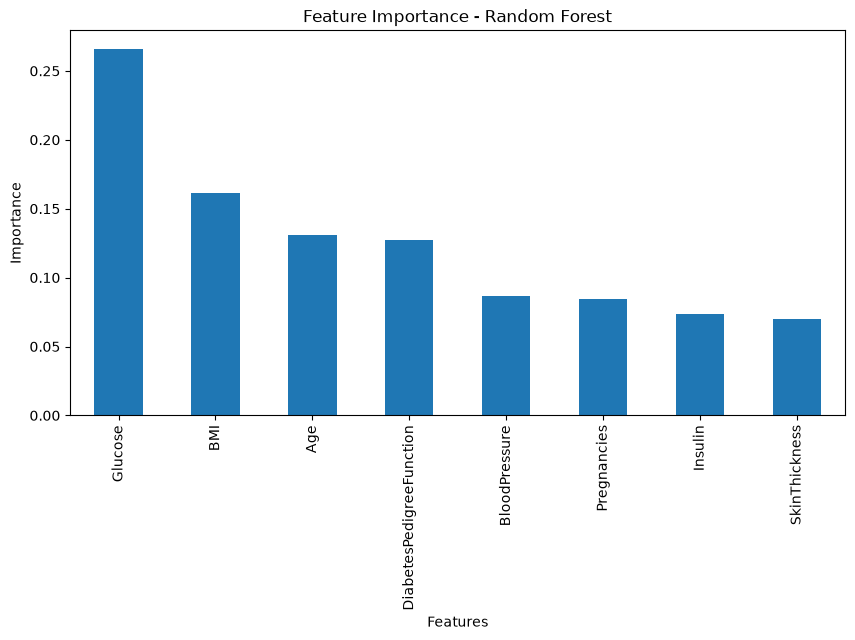

In [59]:
importance.plot(kind="bar", figsize=(10, 5))
plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [60]:
import numpy as np

clean_df = df.copy()

zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

clean_df[zero_as_missing] = clean_df[zero_as_missing].replace(0, np.nan)

print(clean_df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [61]:
X = clean_df.drop("Outcome", axis=1)
y = clean_df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [62]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

print("Logistic Regression pipeline ready!")

Logistic Regression pipeline ready!


In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

print("Random Forest pipeline ready!")

Random Forest pipeline ready!


In [64]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

print("Random Forest pipeline ready!")

Random Forest pipeline ready!


In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (614, 8)
Test : (154, 8)


In [66]:
lr_pred = lr_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

print("Logistic Regression:", lr_pred[:10])
print("Random Forest:", rf_pred[:10])

NotFittedError: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [71]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [73]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {
    "Logistic Regression": [
        accuracy_score(y_test, lr_pred),
        precision_score(y_test, lr_pred),
        recall_score(y_test, lr_pred),
        f1_score(y_test, lr_pred)
    ],
    "Random Forest": [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred)
    ]
}

comparison = pd.DataFrame(
    results,
    index=["Accuracy", "Precision", "Recall", "F1 Score"]
)

comparison

NameError: name 'lr_pred' is not defined

In [75]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (614, 8)
Test : (154, 8)


In [77]:
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

print("Both models trained successfully!")

Both models trained successfully!


In [78]:
lr_pred = lr_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

print("Logistic Regression:", lr_pred[:10])
print("Random Forest:", rf_pred[:10])

Logistic Regression: [1 0 0 0 0 0 0 1 0 1]
Random Forest: [1 0 0 0 0 0 0 1 0 1]


In [79]:
lr_pred = lr_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

print("Logistic Regression:", lr_pred[:10])
print("Random Forest:", rf_pred[:10])

Logistic Regression: [1 0 0 0 0 0 0 1 0 1]
Random Forest: [1 0 0 0 0 0 0 1 0 1]


In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("LOGISTIC REGRESSION")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

print("\nRANDOM FOREST")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

LOGISTIC REGRESSION
Accuracy : 0.7077922077922078
Precision: 0.6
Recall   : 0.5
F1 Score : 0.5454545454545454

RANDOM FOREST
Accuracy : 0.7402597402597403
Precision: 0.6521739130434783
Recall   : 0.5555555555555556
F1 Score : 0.6


In [81]:
results = pd.DataFrame({
    "Logistic Regression": [
        accuracy_score(y_test, lr_pred),
        precision_score(y_test, lr_pred),
        recall_score(y_test, lr_pred),
        f1_score(y_test, lr_pred)
    ],
    "Random Forest": [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred)
    ]
}, index=["Accuracy", "Precision", "Recall", "F1 Score"])

results

,Logistic Regression,Random Forest
Accuracy,0.707792,0.740260
Precision,0.600000,0.652174
Recall,0.500000,0.555556
F1 Score,0.545455,0.600000


In [82]:
results = pd.DataFrame({
    "Logistic Regression": [
        accuracy_score(y_test, lr_pred),
        precision_score(y_test, lr_pred),
        recall_score(y_test, lr_pred),
        f1_score(y_test, lr_pred)
    ],
    "Random Forest": [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred)
    ]
}, index=["Accuracy", "Precision", "Recall", "F1 Score"])

results

,Logistic Regression,Random Forest
Accuracy,0.707792,0.740260
Precision,0.600000,0.652174
Recall,0.500000,0.555556
F1 Score,0.545455,0.600000


In [83]:
from sklearn.metrics import confusion_matrix

lr_cm = confusion_matrix(y_test, lr_pred)

print("Logistic Regression Confusion Matrix:")
print(lr_cm)

Logistic Regression Confusion Matrix:
[[82 18]
 [27 27]]


In [84]:
rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[84 16]
 [24 30]]


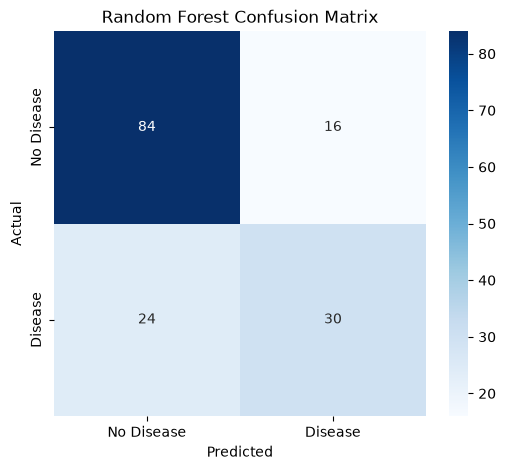

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [86]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("F1 Scores:", rf_scores)
print("Mean F1:", rf_scores.mean())

F1 Scores: [0.68627451 0.62626263 0.68627451 0.6        0.62857143]
Mean F1: 0.6454766148883796


In [87]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10]
}

In [88]:
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verb

In [89]:
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verb

In [90]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best CV F1:
0.6585875078303391


In [91]:
best_model = grid_search.best_estimator_

In [92]:
best_pred = best_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred))
print("Recall   :", recall_score(y_test, best_pred))
print("F1 Score :", f1_score(y_test, best_pred))

Accuracy : 0.7597402597402597
Precision: 0.6888888888888889
Recall   : 0.5740740740740741
F1 Score : 0.6262626262626263


In [93]:
rf_inner = best_model.named_steps["model"]

importance = pd.Series(
    rf_inner.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

Glucose                     0.276399
BMI                         0.164271
DiabetesPedigreeFunction    0.125155
Age                         0.112614
Insulin                     0.088926
BloodPressure               0.081022
Pregnancies                 0.079527
SkinThickness               0.072086
dtype: float64


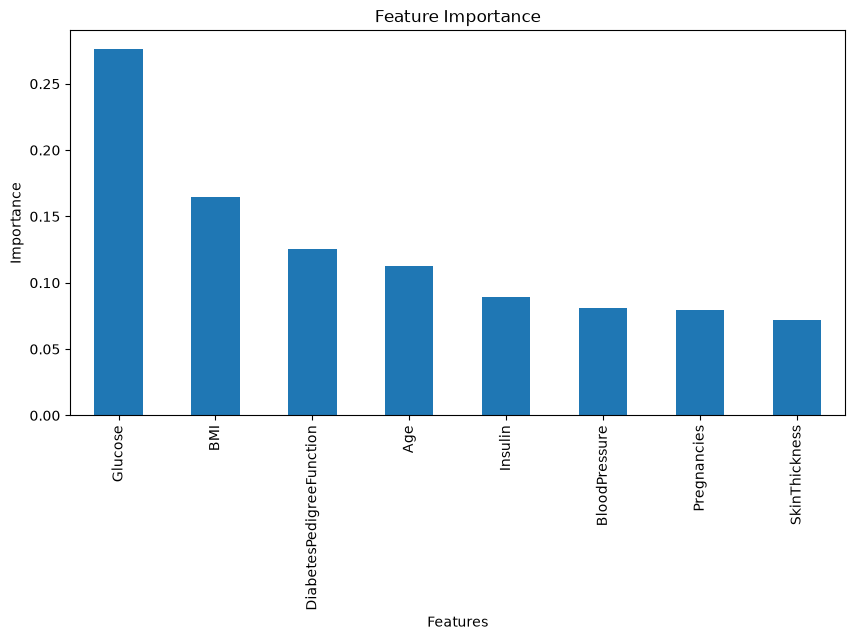

In [94]:
importance.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [95]:
import shap

In [96]:
import shap

In [97]:
explainer = shap.TreeExplainer(rf_model_for_shap)

shap_values = explainer.shap_values(X_test_imputed)

NameError: name 'rf_model_for_shap' is not defined

In [98]:
print("SHAP type:", type(shap_values))
print("SHAP shape:", np.array(shap_values).shape)
print("Expected value:", explainer.expected_value)

NameError: name 'shap_values' is not defined

In [99]:
print("SHAP type:", type(shap_values))
print("SHAP shape:", np.array(shap_values).shape)
print("Expected value:", explainer.expected_value)

NameError: name 'shap_values' is not defined

In [100]:
import shap

In [101]:
rf_model_for_shap = best_model.named_steps["model"]
imputer = best_model.named_steps["imputer"]

X_test_imputed = imputer.transform(X_test)

print("Test data ready:", X_test_imputed.shape)

Test data ready: (154, 8)


In [102]:
explainer = shap.TreeExplainer(rf_model_for_shap)

print("Explainer created successfully!")

Explainer created successfully!


In [103]:
shap_values = explainer.shap_values(X_test_imputed)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


In [104]:
print("SHAP type:", type(shap_values))
print("SHAP shape:", np.array(shap_values).shape)
print("Expected value:", explainer.expected_value)

SHAP type: <class 'numpy.ndarray'>
SHAP shape: (154, 8, 2)
Expected value: [0.65337134 0.34662866]


In [105]:
import shap

In [106]:
rf_model_for_shap = best_model.named_steps["model"]
imputer = best_model.named_steps["imputer"]

X_test_imputed = imputer.transform(X_test)

In [107]:
explainer = shap.TreeExplainer(rf_model_for_shap)
shap_values = explainer.shap_values(X_test_imputed)

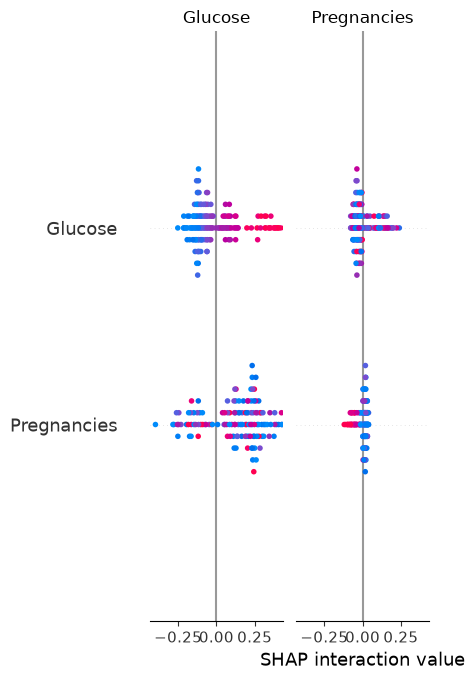

In [108]:
shap.summary_plot(
    shap_values,
    X_test_imputed,
    feature_names=X.columns
)

In [109]:
explainer = shap.TreeExplainer(rf_model_for_shap)
shap_values = explainer.shap_values(X_test_imputed)

In [110]:
import joblib

joblib.dump(
    best_model,
    "../models/disease_prediction_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [111]:
loaded_model = joblib.load(
    "../models/disease_prediction_model.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [112]:
prediction = loaded_model.predict(X_test.iloc[[0]])

print("Prediction:", prediction[0])

Prediction: 1


In [113]:
import joblib

joblib.dump(
    best_model,
    "../models/disease_prediction_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!
